## Facial Expression Recognition using CNN (PyTorch)

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from tqdm import tqdm
import os
# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Data Preprocessing with Augmentation

transform_train = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((48, 48)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])


transform_test = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((48, 48)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

print("Google Drive mounted successfully!")







Using device: cpu
Mounted at /content/drive
Google Drive mounted successfully!


##  Load Dataset from Google Drive

Loading dataset from Google Drive...
Train path: /content/drive/MyDrive/dataset/train
Test path: /content/drive/MyDrive/dataset/test

✓ Dataset loaded successfully from Google Drive!
Training samples (full): 28725
Test samples: 7178
Detected classes: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']

✓ Split completed:
  Training samples: 22980
  Validation samples: 5745
  Test samples: 7178

Classes (7): ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)


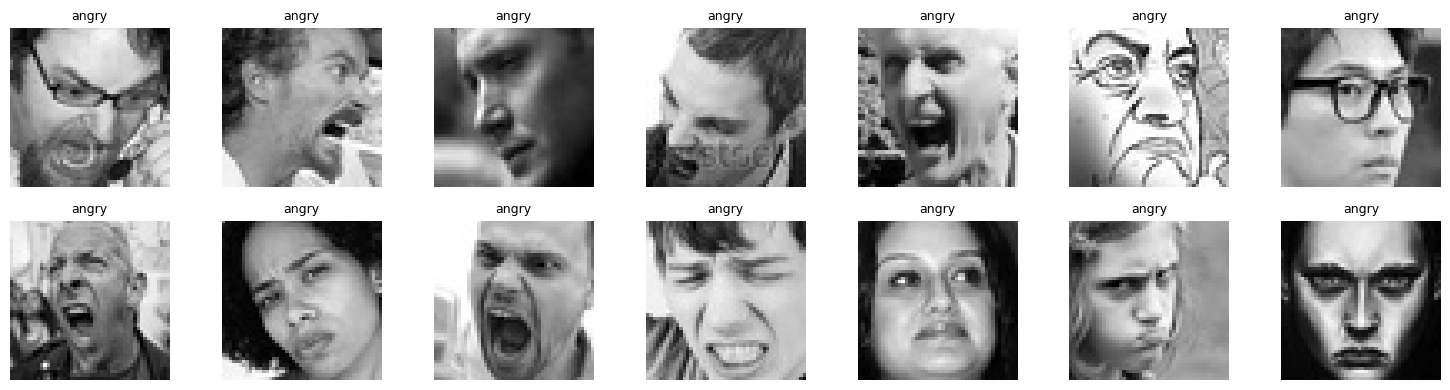

Sample images saved as 'sample_faces.png'


In [7]:



TRAIN_PATH = '/content/drive/MyDrive/dataset/train'
TEST_PATH = '/content/drive/MyDrive/dataset/test'

print("Loading dataset from Google Drive...")
print(f"Train path: {TRAIN_PATH}")
print(f"Test path: {TEST_PATH}")

# Load train and test datasets
# The ImageFolder automatically loads images from subfolders as classes
train_full = datasets.ImageFolder(root=TRAIN_PATH, transform=transform_train)
test_data = datasets.ImageFolder(root=TEST_PATH, transform=transform_test)

print("\n✓ Dataset loaded successfully from Google Drive!")
print(f"Training samples (full): {len(train_full)}")
print(f"Test samples: {len(test_data)}")

# Display detected classes
print(f"Detected classes: {train_full.classes}")

# Split training data into train (80%) and validation (20%)
from torch.utils.data import random_split

train_size = int(0.8 * len(train_full))
val_size = len(train_full) - train_size

train_data, val_data = random_split(
    train_full,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)

print(f"\n✓ Split completed:")
print(f"  Training samples: {len(train_data)}")
print(f"  Validation samples: {len(val_data)}")
print(f"  Test samples: {len(test_data)}")

# Create data loaders
batch_size = 64
train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
val_loader = DataLoader(val_data, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
test_loader = DataLoader(test_data, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

# Get class names
classes = train_full.classes
num_classes = len(classes)
print(f"\nClasses ({num_classes}): {classes}")

#. Visualize Sample Images
def denormalize(img):
    img = img * 0.5 + 0.5  # Denormalize from [-1, 1] to [0, 1]
    return torch.clamp(img, 0, 1)

def plot_sample_images(loader, classes, n=14):
    dataiter = iter(loader)
    images, labels = next(dataiter)

    plt.figure(figsize=(15, 4))
    for i in range(min(n, len(images))):
        plt.subplot(2, 7, i + 1)
        img = denormalize(images[i]).squeeze().numpy()
        plt.imshow(img, cmap='gray')
        plt.title(classes[labels[i]], fontsize=9)
        plt.axis('off')
    plt.tight_layout()
    plt.savefig('sample_faces.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Sample images saved as 'sample_faces.png'")

plot_sample_images(test_loader, classes)

# CNN Model Architecture 

In [ ]:
# CNN Model Architecture 

class FER_CNN(nn.Module):
    def __init__(self, num_classes=7):
        super(FER_CNN, self).__init__()

        # Layer 1
        self.layer1 = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(64),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Dropout(0.25)
        )

        # Layer 2
        self.layer2 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.BatchNorm2d(128),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Dropout(0.25)
        )

        # Layer 3
        self.layer3 = nn.Sequential(
            nn.Conv2d(128, 512, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(512),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Dropout(0.25),
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(512),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Dropout(0.25)
        )

        # Fully Connected Layers
        self.fc1 = nn.Sequential(
            nn.Flatten(),
            nn.Linear(512 * 3 * 3, 256),  
            nn.ReLU(),
            nn.BatchNorm1d(256),
            nn.Dropout(0.25)
        )

        self.fc2 = nn.Sequential(
            nn.Linear(256, 512),
            nn.ReLU(),
            nn.BatchNorm1d(512),
            nn.Dropout(0.25),
            nn.Linear(512, num_classes)  #  No Softmax!
        )

    def forward(self, x):
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.fc1(x)
        x = self.fc2(x)
        return x

# Initialize model
model = FER_CNN(num_classes=num_classes).to(device)
print("\n" + "="*70)
print("MODEL ARCHITECTURE")
print("="*70)
print(model)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nTotal parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")




MODEL ARCHITECTURE
FER_CNN(
  (layer1): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Dropout(p=0.25, inplace=False)
  )
  (layer2): Sequential(
    (0): Conv2d(64, 128, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (1): ReLU()
    (2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Dropout(p=0.25, inplace=False)
  )
  (layer3): Sequential(
    (0): Conv2d(128, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3):

#  Training Setup

In [ ]:


criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

# Training and Validation Functions

def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    all_preds = []
    all_labels = []

    pbar = tqdm(loader, desc='Training', leave=False)
    for images, labels in pbar:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = outputs.max(1)

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

        acc = 100. * np.mean(np.array(all_preds) == np.array(all_labels))
        pbar.set_postfix({'loss': f'{running_loss/len(all_preds)*batch_size:.4f}', 'acc': f'{acc:.2f}%'})

    epoch_loss = running_loss / len(loader)
    epoch_acc = accuracy_score(all_labels, all_preds)
    epoch_f1 = f1_score(all_labels, all_preds, average='weighted')

    return epoch_loss, epoch_acc * 100, epoch_f1

def validate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in tqdm(loader, desc='Validating', leave=False):
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item()
            _, predicted = outputs.max(1)

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    epoch_loss = running_loss / len(loader)
    epoch_acc = accuracy_score(all_labels, all_preds)
    epoch_f1 = f1_score(all_labels, all_preds, average='weighted')

    return epoch_loss, epoch_acc * 100, epoch_f1





#  Training Loop

In [ ]:
#  Training Loop

print("\n" + "="*70)
print("STARTING TRAINING")
print("="*70)

num_epochs = 45
best_val_f1 = 0
patience = 10
patience_counter = 0

history = {
    'train_loss': [], 'train_acc': [], 'train_f1': [],
    'val_loss': [], 'val_acc': [], 'val_f1': []
}

for epoch in range(num_epochs):
    print(f"\nEpoch [{epoch+1}/{num_epochs}]")
    print("-" * 70)

    train_loss, train_acc, train_f1 = train_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc, val_f1 = validate(model, val_loader, criterion, device)

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['train_f1'].append(train_f1)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    history['val_f1'].append(val_f1)

    print(f"Train - Loss: {train_loss:.4f}, Acc: {train_acc:.2f}%, F1: {train_f1:.4f}")
    print(f"Val   - Loss: {val_loss:.4f}, Acc: {val_acc:.2f}%, F1: {val_f1:.4f}")
    print(f"LR: {optimizer.param_groups[0]['lr']:.6f}")

    scheduler.step(val_loss)

    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        torch.save(model.state_dict(), 'best_fer_model.pth')
        print(f"✓ Best model saved! (Val F1: {best_val_f1:.4f})")
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"\nEarly stopping at epoch {epoch+1}")
            break

model.load_state_dict(torch.load('best_fer_model.pth'))
print(f"\n{'='*70}")
print("Best model loaded!")
print(f"Best Validation F1: {best_val_f1:.4f}")
print("="*70)


STARTING TRAINING

Epoch [1/45]
----------------------------------------------------------------------


Train - Loss: 1.8677, Acc: 24.45%, F1: 0.2279
Val   - Loss: 1.7106, Acc: 31.16%, F1: 0.2733
LR: 0.001000
✓ Best model saved! (Val F1: 0.2733)

Epoch [2/45]
----------------------------------------------------------------------


Train - Loss: 1.6599, Acc: 34.13%, F1: 0.3125
Val   - Loss: 1.5859, Acc: 39.86%, F1: 0.3664
LR: 0.001000
✓ Best model saved! (Val F1: 0.3664)

Epoch [3/45]
----------------------------------------------------------------------


Train - Loss: 1.4739, Acc: 42.72%, F1: 0.4059
Val   - Loss: 1.3115, Acc: 49.28%, F1: 0.4848
LR: 0.001000
✓ Best model saved! (Val F1: 0.4848)

Epoch [4/45]
----------------------------------------------------------------------


Train - Loss: 1.3598, Acc: 47.11%, F1: 0.4547
Val   - Loss: 1.2612, Acc: 52.27%, F1: 0.4928
LR: 0.001000
✓ Best model saved! (Val F1: 0.4928)

Epoch [5/45]
----------------------------------------------------------------------


...

Train - Loss: 0.7917, Acc: 70.47%, F1: 0.7022
Val   - Loss: 0.9137, Acc: 67.48%, F1: 0.6713
LR: 0.000250
✓ Best model saved! (Val F1: 0.6713)

Epoch [42/45]
----------------------------------------------------------------------


Train - Loss: 0.7890, Acc: 70.53%, F1: 0.7030
Val   - Loss: 0.9487, Acc: 67.08%, F1: 0.6668
LR: 0.000250

Epoch [43/45]
----------------------------------------------------------------------


Train - Loss: 0.7892, Acc: 70.14%, F1: 0.6993
Val   - Loss: 0.9021, Acc: 67.57%, F1: 0.6727
LR: 0.000250
✓ Best model saved! (Val F1: 0.6727)

Epoch [44/45]
----------------------------------------------------------------------


Train - Loss: 0.7758, Acc: 71.24%, F1: 0.7099
Val   - Loss: 0.9122, Acc: 67.01%, F1: 0.6662
LR: 0.000250

Epoch [45/45]
----------------------------------------------------------------------


Train - Loss: 0.7662, Acc: 71.31%, F1: 0.7109
Val   - Loss: 0.9550, Acc: 67.45%, F1: 0.6705
LR: 0.000250

Best model loaded!
Best Validation F1: 0.6727


In [ ]:

save_path = "/content/drive/MyDrive/best_fer_model.pth"

# Save model to Drive
torch.save(model.state_dict(), save_path)
print(f"\nModel successfully saved to: {save_path}")


Model successfully saved to: /content/drive/MyDrive/best_fer_model.pth


In [18]:
# for cpu
model.load_state_dict(torch.load("/content/drive/MyDrive/dataset/best_fer_model.pth",
                                 map_location=torch.device('cpu')))
model.eval()


FER_CNN(
  (layer1): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU()
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Dropout(p=0.25, inplace=False)
  )
  (layer2): Sequential(
    (0): Conv2d(64, 128, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (1): ReLU()
    (2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Dropout(p=0.25, inplace=False)
  )
  (layer3): Sequential(
    (0): Conv2d(128, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): MaxPool2d(kernel_si

In [ ]:
model.load_state_dict(torch.load("/content/drive/MyDrive/dataset/best_fer_model.pth"))
model.eval()


# Test Set Evaluation

In [ ]:


print("\n" + "="*70)
print("EVALUATING ON TEST SET")
print("="*70)

def get_all_predictions(model, loader, device):
    model.eval()
    all_preds = []
    all_labels = []
    all_probs = []

    with torch.no_grad():
        for images, labels in tqdm(loader, desc='Testing'):
            images = images.to(device)
            outputs = model(images)
            probs = torch.softmax(outputs, dim=1)
            _, predicted = outputs.max(1)

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.numpy())
            all_probs.extend(probs.cpu().numpy())

    return np.array(all_labels), np.array(all_preds), np.array(all_probs)

y_true, y_pred, y_probs = get_all_predictions(model, test_loader, device)

test_acc = accuracy_score(y_true, y_pred)
test_f1 = f1_score(y_true, y_pred, average='weighted')

print(f"\n{'='*70}")
print("FINAL TEST RESULTS")
print('='*70)
print(f"✓ Test Accuracy: {test_acc:.4f} ({test_acc*100:.2f}%)")
print(f"✓ Test F1 Score: {test_f1:.4f}")
print('='*70)




EVALUATING ON TEST SET


Testing:   0%|          | 0/113 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:666: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  warnings.warn(warn_msg)
Testing: 100%|██████████| 113/113 [01:53<00:00,  1.00s/it]


FINAL TEST RESULTS
✓ Test Accuracy: 0.6762 (67.62%)
✓ Test F1 Score: 0.6727


# Training History Visualization

In [ ]:


def plot_training_history(history):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    epochs_range = range(1, len(history['train_loss']) + 1)

    axes[0].plot(epochs_range, history['train_loss'], label='Training', linewidth=2, marker='o', markersize=4)
    axes[0].plot(epochs_range, history['val_loss'], label='Validation', linewidth=2, marker='s', markersize=4)
    axes[0].set_title('Loss', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    axes[1].plot(epochs_range, history['train_acc'], label='Training', linewidth=2, marker='o', markersize=4)
    axes[1].plot(epochs_range, history['val_acc'], label='Validation', linewidth=2, marker='s', markersize=4)
    axes[1].set_title('Accuracy', fontsize=14, fontweight='bold')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy (%)')
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    axes[2].plot(epochs_range, history['train_f1'], label='Training', linewidth=2, marker='o', markersize=4)
    axes[2].plot(epochs_range, history['val_f1'], label='Validation', linewidth=2, marker='s', markersize=4)
    axes[2].set_title('F1 Score', fontsize=14, fontweight='bold')
    axes[2].set_xlabel('Epoch')
    axes[2].set_ylabel('F1 Score')
    axes[2].legend()
    axes[2].grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig('training_history.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("\n✓ Training history saved")

plot_training_history(history)

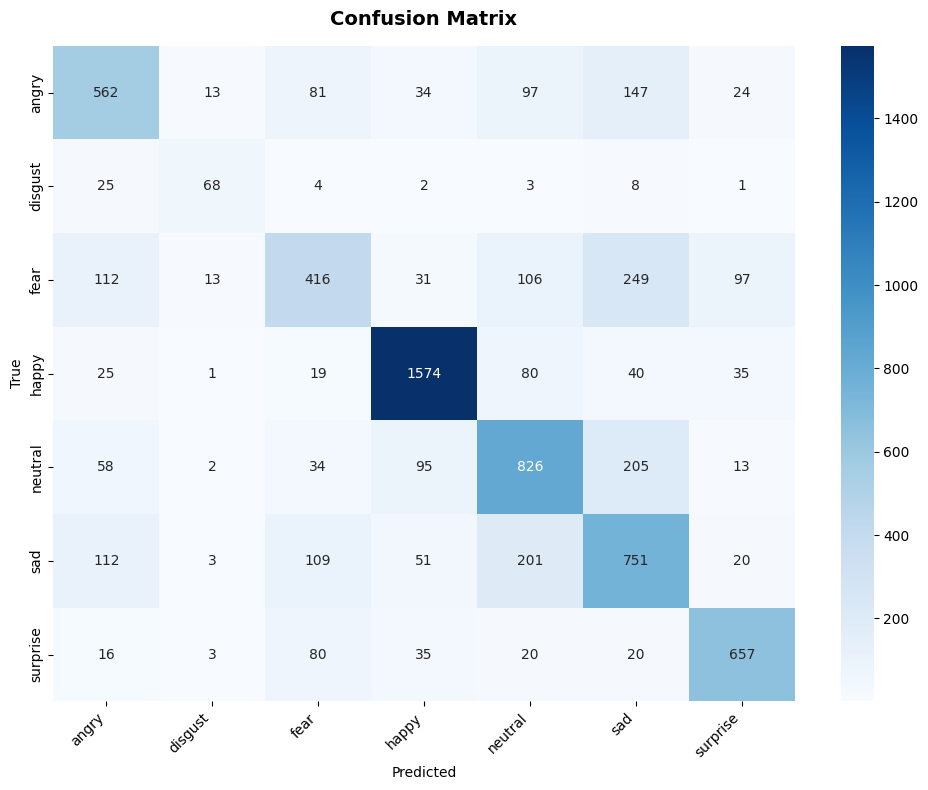

✓ Confusion matrix saved


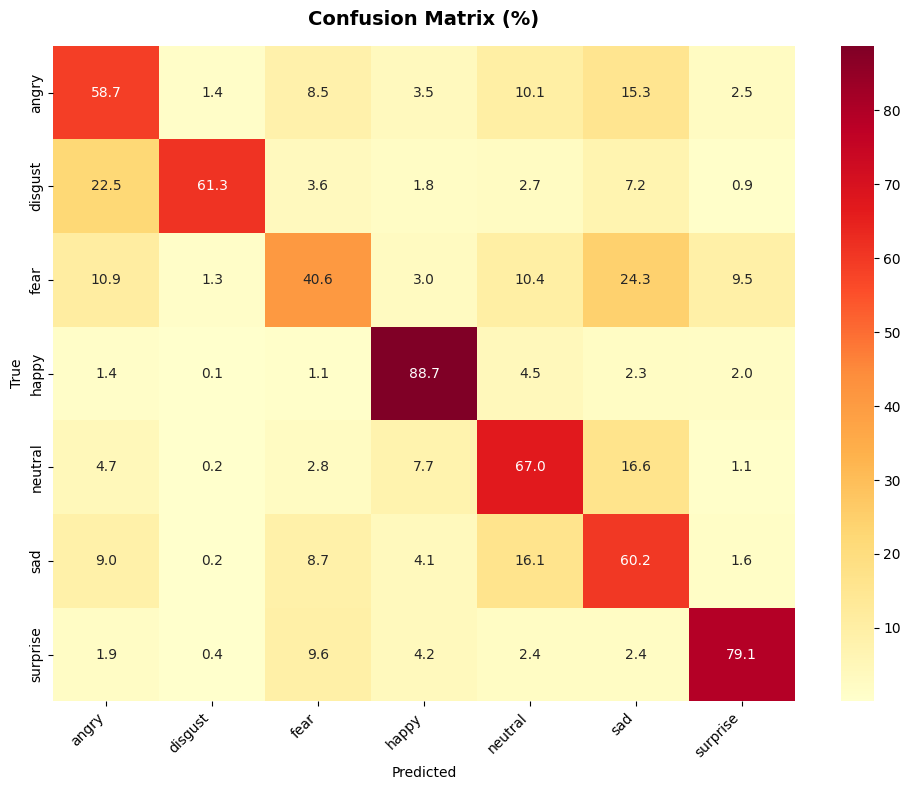

✓ Percentage confusion matrix saved


In [20]:
 # Confusion Matrix

def plot_confusion_matrix(y_true, y_pred, classes):
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
    plt.title('Confusion Matrix', fontsize=14, fontweight='bold', pad=15)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("✓ Confusion matrix saved")

    cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm_percent, annot=True, fmt='.1f', cmap='YlOrRd', xticklabels=classes, yticklabels=classes)
    plt.title('Confusion Matrix (%)', fontsize=14, fontweight='bold', pad=15)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.savefig('confusion_matrix_percent.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("✓ Percentage confusion matrix saved")

plot_confusion_matrix(y_true, y_pred, classes)

# Classification Report

In [ ]:


print("\n" + "="*70)
print("CLASSIFICATION REPORT")
print("="*70)
print(classification_report(y_true, y_pred, target_names=classes, digits=4))

print("\nPER-CLASS PERFORMANCE:")
print("="*70)
cm = confusion_matrix(y_true, y_pred)
per_class_acc = cm.diagonal() / cm.sum(axis=1)

for i, (name, acc) in enumerate(zip(classes, per_class_acc)):
    class_f1 = f1_score(y_true == i, y_pred == i)
    support = cm.sum(axis=1)[i]
    print(f"{name:12s}: Acc: {acc:.4f} ({acc*100:5.2f}%), F1: {class_f1:.4f}, Support: {support:5d}")



CLASSIFICATION REPORT
              precision    recall  f1-score   support

       angry     0.6176    0.5866    0.6017       958
     disgust     0.6602    0.6126    0.6355       111
        fear     0.5599    0.4062    0.4709      1024
       happy     0.8639    0.8873    0.8754      1774
     neutral     0.6197    0.6699    0.6438      1233
         sad     0.5289    0.6022    0.5632      1247
    surprise     0.7757    0.7906    0.7831       831

    accuracy                         0.6762      7178
   macro avg     0.6608    0.6508    0.6534      7178
weighted avg     0.6741    0.6762    0.6727      7178


PER-CLASS PERFORMANCE:
angry       : Acc: 0.5866 (58.66%), F1: 0.6017, Support:   958
disgust     : Acc: 0.6126 (61.26%), F1: 0.6355, Support:   111
fear        : Acc: 0.4062 (40.62%), F1: 0.4709, Support:  1024
happy       : Acc: 0.8873 (88.73%), F1: 0.8754, Support:  1774
neutral     : Acc: 0.6699 (66.99%), F1: 0.6438, Support:  1233
sad         : Acc: 0.6022 (60.22%), F1: 0